<a href="https://colab.research.google.com/github/ayush2459/APITesting_Python_RequestModule/blob/master/movie_recomendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

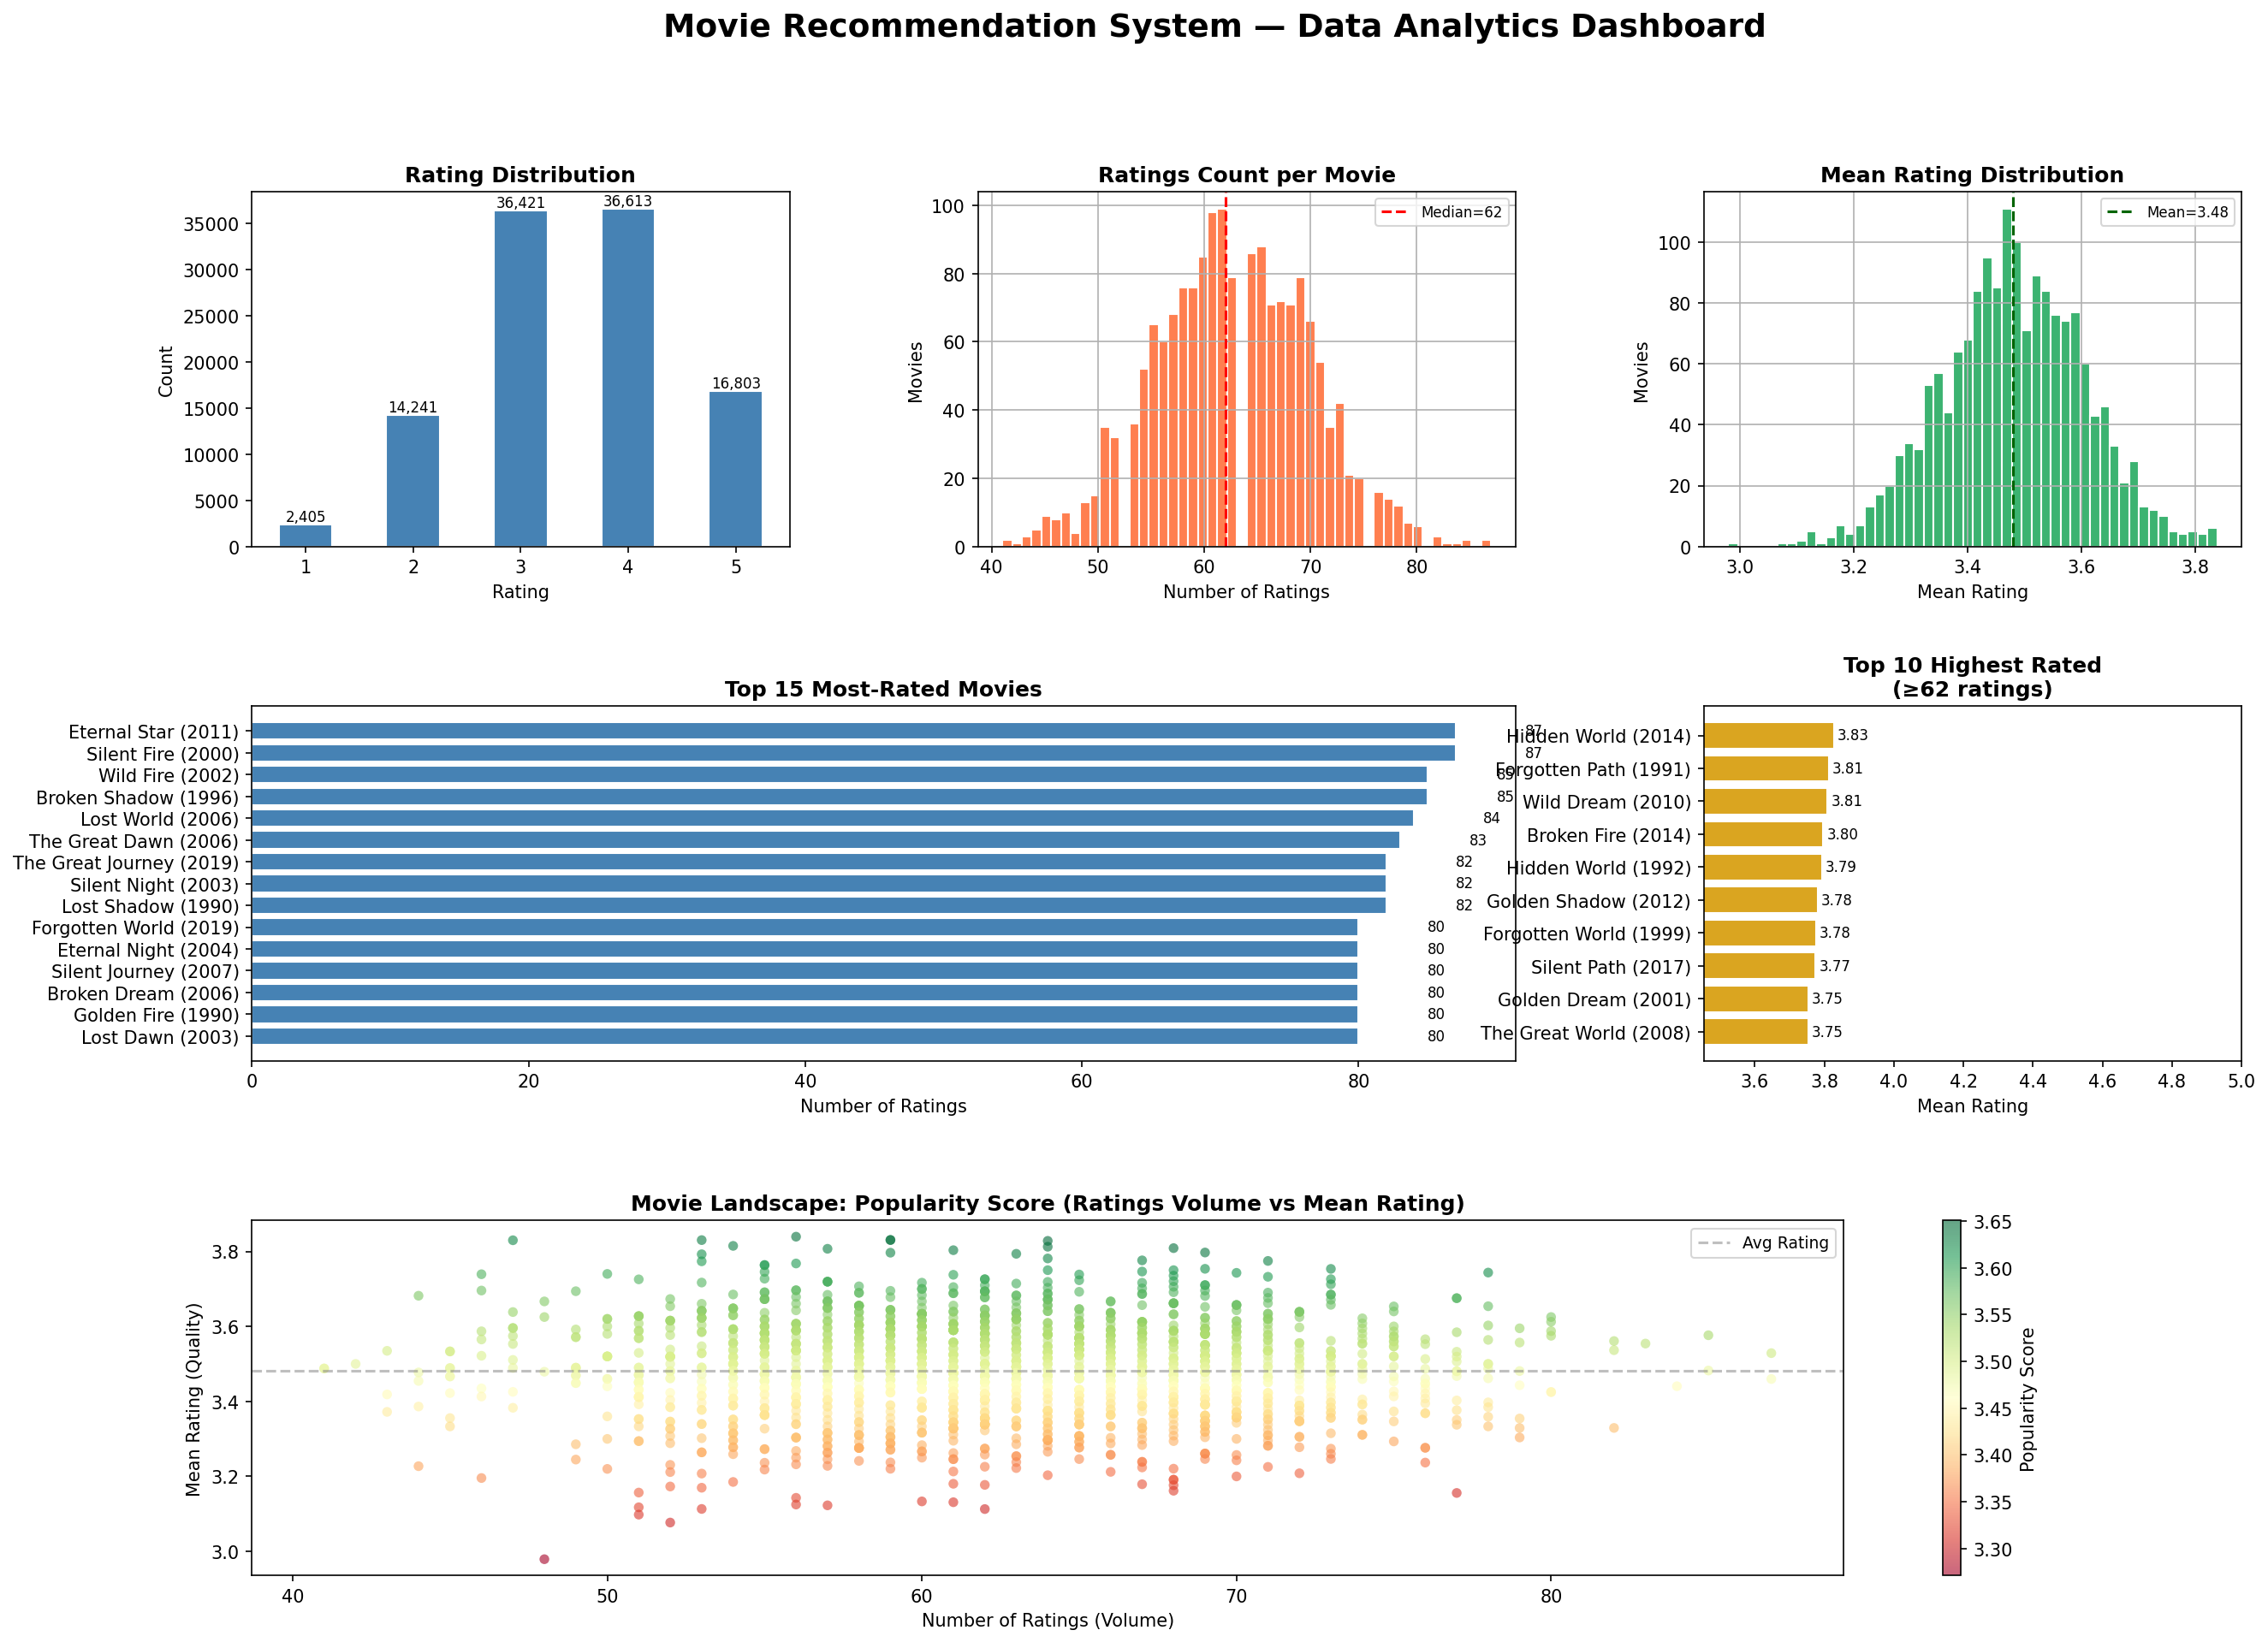


═══════════════════════════════════════════════════════
  🎬 TOP 10 MOVIES BY POPULARITY SCORE
═══════════════════════════════════════════════════════
                       Mean Rating  Num Ratings  Popularity Score
title                                                            
Hidden World (2014)           3.83           64             3.650
Wild Dream (2010)             3.81           68             3.646
Golden Dream (2014)           3.83           59             3.645
Dark Journey (1996)           3.83           59             3.645
Eternal Shadow (2005)         3.84           56             3.644
Forgotten Path (1991)         3.81           64             3.643
Broken Fire (2014)            3.80           69             3.641
Lost Shadow (1991)            3.83           53             3.635
Eternal Dream (1999)          3.80           61             3.634
Hidden World (1992)           3.79           63             3.632

═══════════════════════════════════════════════════════


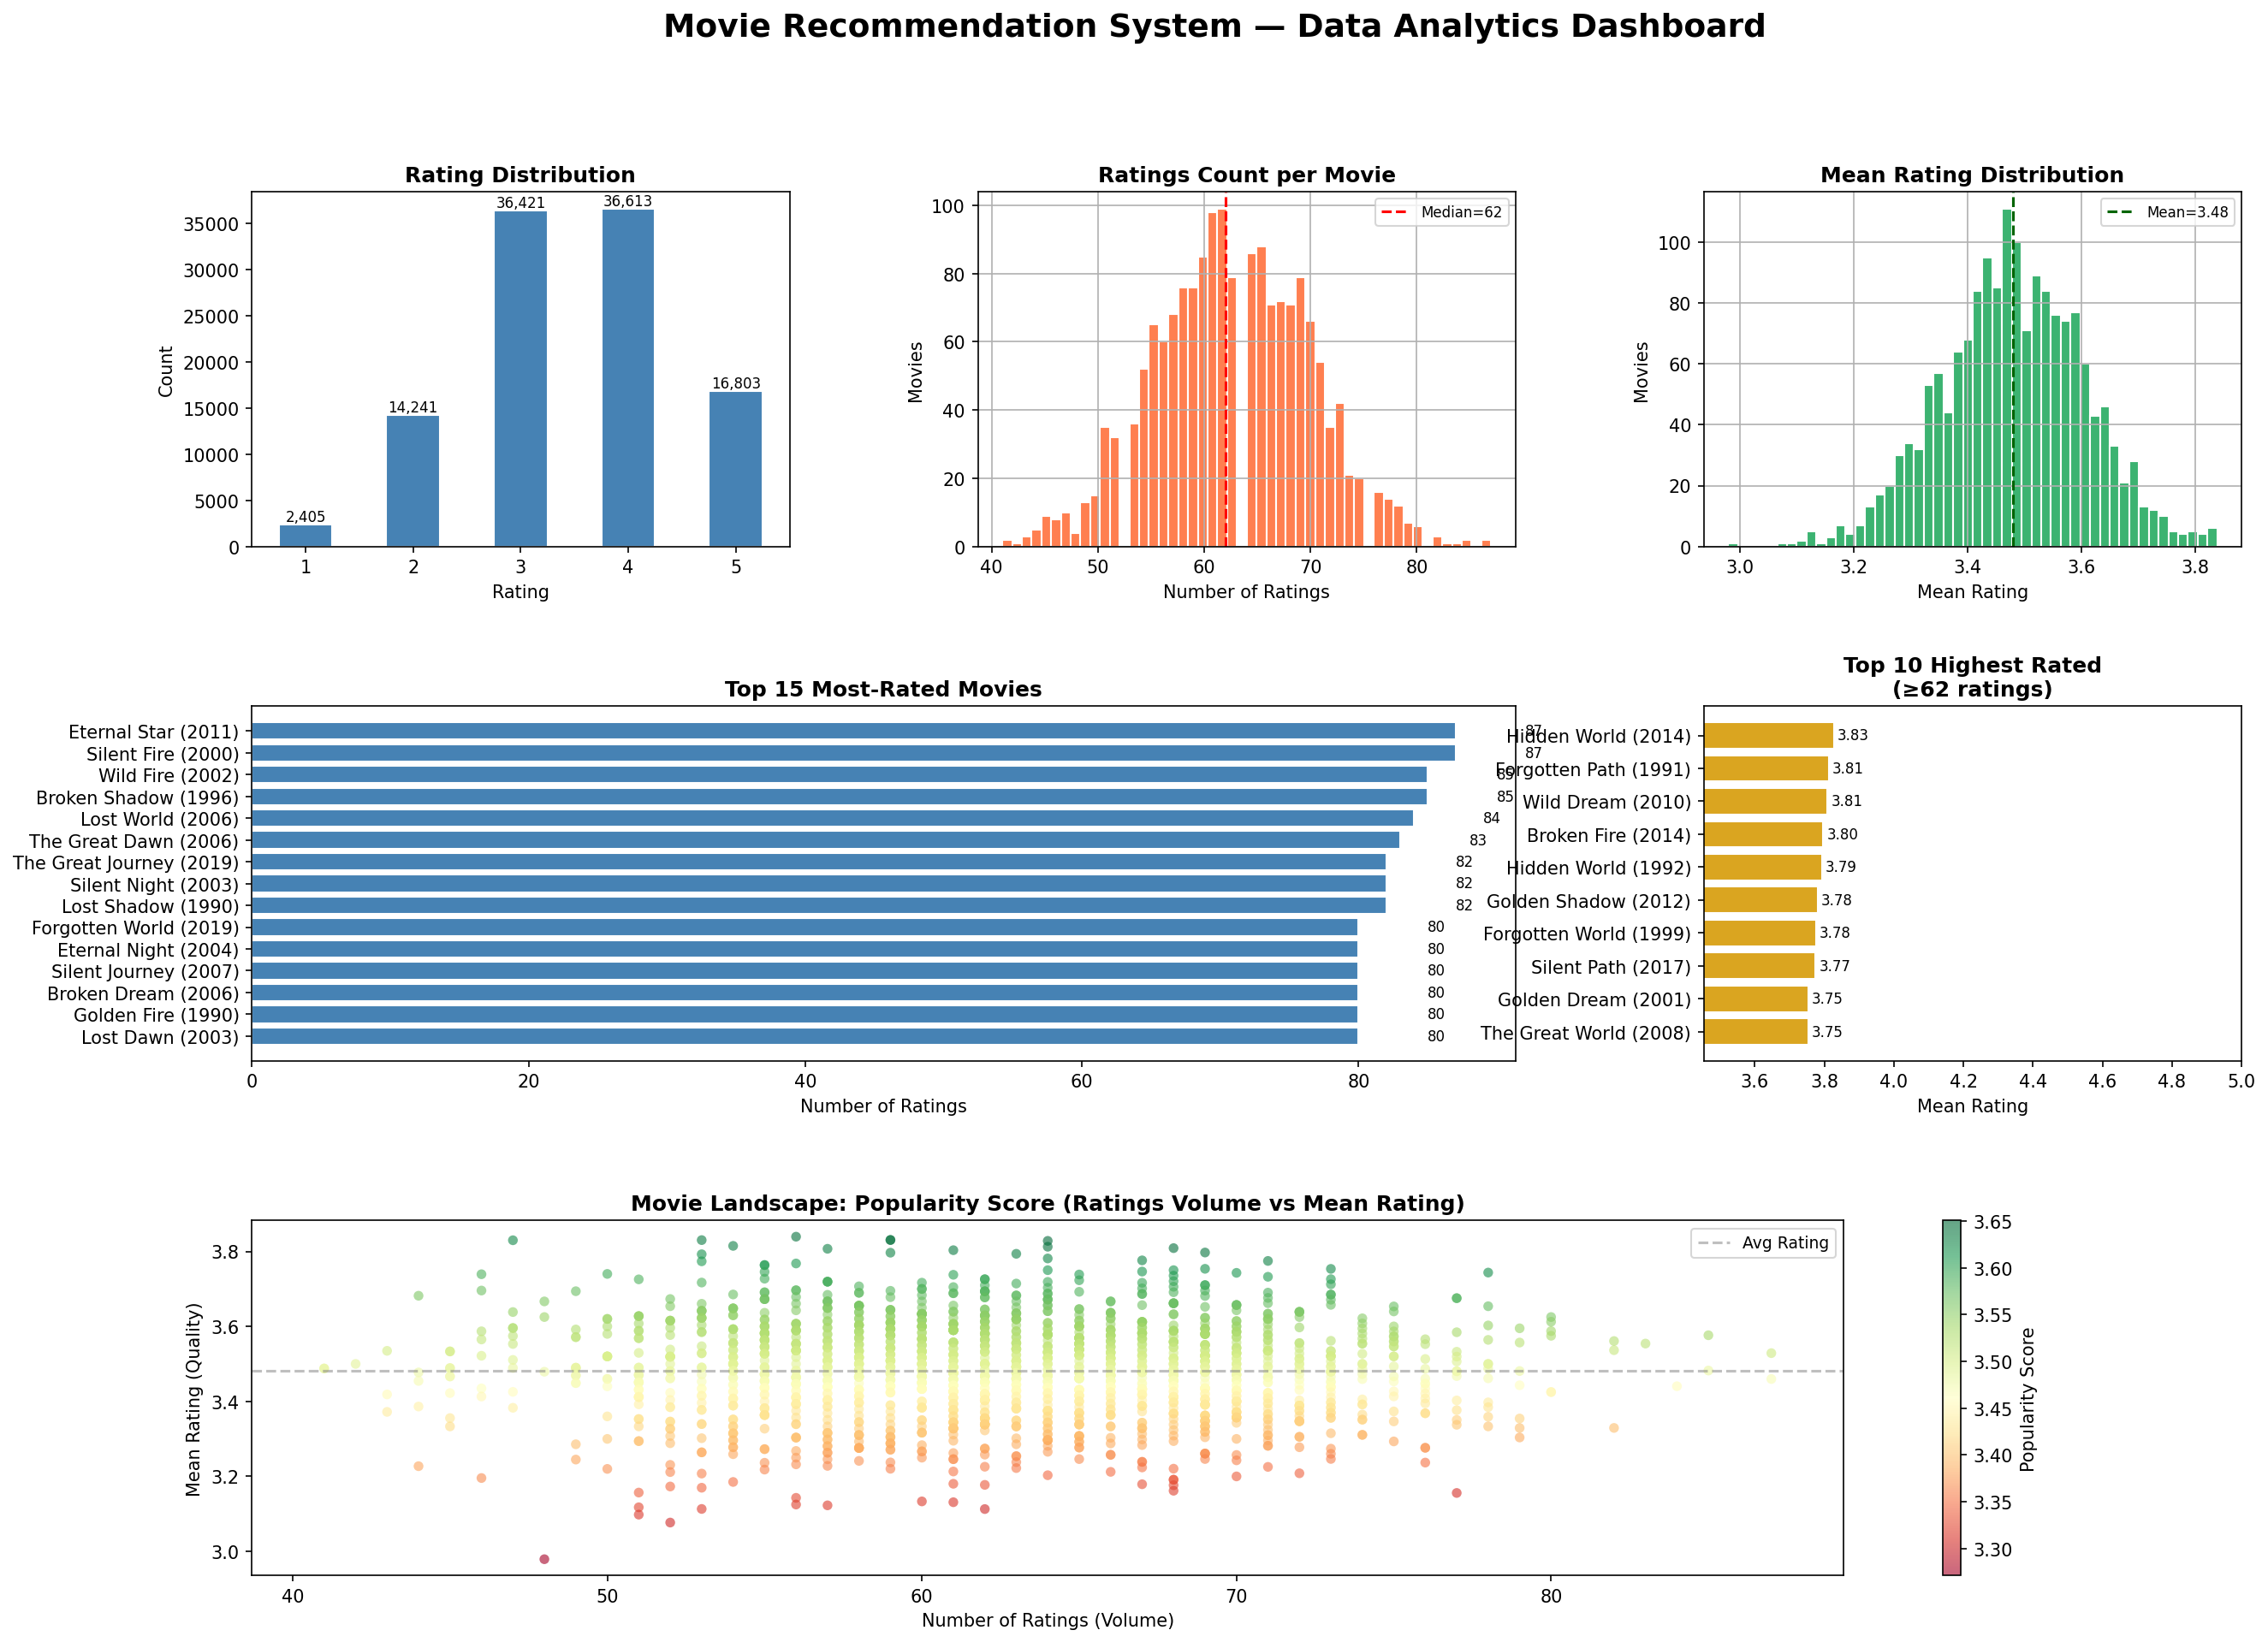

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  Downloading: recommendation_dashboard.png
  ⚠️  Skipped (not found): item_based_recs.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  Downloading: user_based_recs.csv

  ☁️  Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✅ Saved to Drive → /content/drive/MyDrive/recommendation_dashboard.png
  ✅ Saved to Drive → /content/drive/MyDrive/user_based_recs.csv



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import logging
import json
import os
import warnings
warnings.filterwarnings('ignore')

# ── LOGGING ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
MIN_RATINGS_THRESHOLD = 100   # minimum ratings a movie must have to be included
MIN_USER_RATINGS      = 50    # minimum ratings a user must have given
TOP_N_DEFAULT         = 10    # default number of recommendations


# ── STAGE 1: ETL PIPELINE ─────────────────────────────────────────────────────

class ETLPipeline:
    """
    Load → Clean → Transform → Merge

    Handles the full data ingestion pipeline from raw TSV/CSV files
    to a clean, analysis-ready DataFrame.
    """

    @staticmethod
    def load(ratings_path: str, titles_path: str) -> pd.DataFrame:
        """
        Stage 1 — Ingest raw ratings and movie titles, merge into one DataFrame.

        Args:
            ratings_path: Path to ratings TSV (user_id, item_id, rating, timestamp)
            titles_path:  Path to Movie_Id_Titles CSV

        Returns:
            Merged raw DataFrame
        """
        logger.info("── ETL Stage 1: Loading data ──")
        column_names = ['user_id', 'item_id', 'rating', 'timestamp']
        ratings      = pd.read_csv(ratings_path, sep='\t', names=column_names)
        titles       = pd.read_csv(titles_path)
        data         = pd.merge(ratings, titles, on='item_id')
        logger.info("Loaded %d ratings across %d unique movies from %d users.",
                    len(data), data['item_id'].nunique(), data['user_id'].nunique())
        return data

    @staticmethod
    def clean(data: pd.DataFrame) -> pd.DataFrame:
        """
        Stage 2 — Remove nulls, duplicates, and out-of-range ratings.

        Returns:
            Cleaned DataFrame
        """
        logger.info("── ETL Stage 2: Cleaning data ──")
        before = len(data)
        data = data.dropna(subset=['user_id', 'item_id', 'rating', 'title'])
        data = data.drop_duplicates(subset=['user_id', 'item_id'])
        data = data[data['rating'].between(1, 5)]
        logger.info("Cleaned: %d → %d rows (%d removed).",
                    before, len(data), before - len(data))
        return data

    @staticmethod
    def transform(data: pd.DataFrame) -> pd.DataFrame:
        """
        Stage 3 — Filter low-signal movies and users, add derived features.

        Returns:
            Transformed DataFrame ready for modelling
        """
        logger.info("── ETL Stage 3: Transforming data ──")

        # Filter movies with too few ratings (noise reduction)
        movie_counts = data.groupby('title')['rating'].count()
        valid_movies = movie_counts[movie_counts >= MIN_RATINGS_THRESHOLD].index
        data = data[data['title'].isin(valid_movies)]

        # Filter users who haven't rated enough movies
        user_counts = data.groupby('user_id')['rating'].count()
        valid_users = user_counts[user_counts >= MIN_USER_RATINGS].index
        data = data[data['user_id'].isin(valid_users)]

        # Derived: normalised rating per user (removes user bias)
        data = data.copy()
        user_means         = data.groupby('user_id')['rating'].transform('mean')
        data['rating_norm'] = data['rating'] - user_means

        logger.info("After transform: %d ratings | %d movies | %d users.",
                    len(data), data['title'].nunique(), data['user_id'].nunique())
        return data

    @classmethod
    def run(cls, ratings_path: str, titles_path: str) -> pd.DataFrame:
        """Run the full ETL pipeline end-to-end."""
        logger.info("=" * 55)
        logger.info("ETL Pipeline started")
        logger.info("=" * 55)
        data = cls.load(ratings_path, titles_path)
        data = cls.clean(data)
        data = cls.transform(data)
        logger.info("ETL Pipeline complete.")
        logger.info("=" * 55)
        return data


# ── STAGE 2: FEATURE ENGINEERING ─────────────────────────────────────────────

class FeatureEngine:
    """Build movie stats and user-item matrices for similarity computation."""

    @staticmethod
    def movie_stats(data: pd.DataFrame) -> pd.DataFrame:
        """
        Compute per-movie statistics:
          - mean rating
          - number of ratings
          - rating std deviation
          - popularity score (weighted)
        """
        stats = pd.DataFrame({
            'mean_rating':  data.groupby('title')['rating'].mean(),
            'num_ratings':  data.groupby('title')['rating'].count(),
            'rating_std':   data.groupby('title')['rating'].std().fillna(0),
        })
        # Weighted popularity: balances mean rating with volume
        C  = stats['mean_rating'].mean()   # global mean
        m  = stats['num_ratings'].quantile(0.70)  # minimum votes threshold
        v  = stats['num_ratings']
        R  = stats['mean_rating']
        stats['popularity_score'] = (v / (v + m)) * R + (m / (v + m)) * C
        return stats.sort_values('popularity_score', ascending=False)

    @staticmethod
    def user_item_matrix(data: pd.DataFrame) -> pd.DataFrame:
        """
        Build a User × Movie rating matrix.
        Rows = users, Columns = movies, Values = ratings (NaN if not rated).
        """
        logger.info("Building user-item matrix...")
        matrix = data.pivot_table(index='user_id', columns='title', values='rating')
        logger.info("Matrix shape: %d users × %d movies", *matrix.shape)
        return matrix


# ── STAGE 3: RECOMMENDATION ENGINE ───────────────────────────────────────────

class RecommendationEngine:
    """
    Similarity-based collaborative filtering engine.

    Supports:
      - Item-based collaborative filtering (movie → similar movies)
      - User-based collaborative filtering  (user → personalised picks)
      - Hybrid mode                         (combines both signals)
    """

    def __init__(self, data: pd.DataFrame):
        self.data        = data
        self.stats       = FeatureEngine.movie_stats(data)
        self.matrix      = FeatureEngine.user_item_matrix(data)
        self._corr_cache = {}   # cache correlation matrix (expensive to compute)
        logger.info("RecommendationEngine ready.")

    def _get_corr_matrix(self) -> pd.DataFrame:
        """Compute (and cache) movie-movie Pearson correlation matrix."""
        if not self._corr_cache:
            logger.info("Computing movie-movie correlation matrix (this may take a moment)...")
            self._corr_cache['matrix'] = self.matrix.corr(method='pearson', min_periods=50)
            logger.info("Correlation matrix computed.")
        return self._corr_cache['matrix']

    # ── Item-Based ────────────────────────────────────────────────────────────

    def item_based(self, movie_title: str, top_n: int = TOP_N_DEFAULT) -> pd.DataFrame:
        """
        Item-based collaborative filtering.
        Finds movies most correlated with the given movie using Pearson similarity.

        Args:
            movie_title: Name of the reference movie
            top_n:       Number of recommendations to return

        Returns:
            DataFrame of recommended movies with correlation and stats
        """
        corr_matrix = self._get_corr_matrix()

        if movie_title not in corr_matrix.columns:
            # Fuzzy match: find closest title
            matches = [t for t in corr_matrix.columns
                       if movie_title.lower() in t.lower()]
            if not matches:
                logger.warning("Movie '%s' not found in dataset.", movie_title)
                return pd.DataFrame()
            movie_title = matches[0]
            logger.info("Fuzzy matched to: '%s'", movie_title)

        similar = pd.DataFrame(
            corr_matrix[movie_title].dropna(),
            columns=['correlation']
        )
        similar = similar.join(self.stats[['num_ratings', 'mean_rating', 'popularity_score']])
        similar = similar[similar['num_ratings'] >= MIN_RATINGS_THRESHOLD]
        similar = similar[similar.index != movie_title]   # exclude self
        similar = similar.sort_values('correlation', ascending=False).head(top_n)

        logger.info("Item-based: Top %d movies similar to '%s'", top_n, movie_title)
        return similar.reset_index().rename(columns={'title': 'Movie'})

    # ── User-Based ────────────────────────────────────────────────────────────

    def user_based(self, user_id: int, top_n: int = TOP_N_DEFAULT) -> pd.DataFrame:
        """
        User-based collaborative filtering.
        Finds movies highly rated by users similar to the given user.

        Args:
            user_id: Target user ID
            top_n:   Number of recommendations to return

        Returns:
            DataFrame of recommended movies with predicted rating
        """
        if user_id not in self.matrix.index:
            logger.warning("User %d not found in dataset.", user_id)
            return pd.DataFrame()

        user_ratings = self.matrix.loc[user_id].dropna()

        # Movies the user hasn't seen yet
        unseen = self.matrix.columns[self.matrix.loc[user_id].isna()]

        # Find similar users (Pearson correlation between users)
        user_corr = self.matrix.T.corrwith(user_ratings)
        similar_users = user_corr.dropna().sort_values(ascending=False)
        similar_users = similar_users[similar_users.index != user_id].head(20)

        if similar_users.empty:
            logger.warning("No similar users found for user %d.", user_id)
            return pd.DataFrame()

        # Predict ratings for unseen movies
        predictions = {}
        for movie in unseen:
            movie_ratings = self.matrix[movie].dropna()
            common_users  = similar_users.index.intersection(movie_ratings.index)
            if len(common_users) < 3:
                continue
            weights       = similar_users[common_users]
            weighted_sum  = (movie_ratings[common_users] * weights).sum()
            weight_total  = weights.abs().sum()
            if weight_total > 0:
                predictions[movie] = weighted_sum / weight_total

        if not predictions:
            logger.warning("No predictions generated for user %d.", user_id)
            return pd.DataFrame()

        pred_df = pd.DataFrame.from_dict(
            predictions, orient='index', columns=['predicted_rating']
        )
        pred_df = pred_df.join(self.stats[['num_ratings', 'mean_rating']])
        pred_df = pred_df.sort_values('predicted_rating', ascending=False).head(top_n)
        logger.info("User-based: Top %d recs for user %d", top_n, user_id)
        return pred_df.reset_index().rename(columns={'index': 'Movie'})

    # ── Hybrid ────────────────────────────────────────────────────────────────

    def hybrid(self, user_id: int, movie_title: str,
               top_n: int = TOP_N_DEFAULT) -> pd.DataFrame:
        """
        Hybrid recommendation: combines item-based and user-based signals.

        Weights:
          - 60% item-based similarity
          - 40% user-based predicted rating

        Args:
            user_id:     Target user ID
            movie_title: Seed movie they liked
            top_n:       Number of recommendations

        Returns:
            DataFrame with hybrid score
        """
        item_recs = self.item_based(movie_title, top_n=top_n * 2)
        user_recs = self.user_based(user_id, top_n=top_n * 2)

        if item_recs.empty and user_recs.empty:
            return pd.DataFrame()

        if item_recs.empty:
            return user_recs.head(top_n)
        if user_recs.empty:
            return item_recs.head(top_n)

        item_recs = item_recs.set_index('Movie')[['correlation']].rename(
            columns={'correlation': 'item_score'})
        user_recs = user_recs.set_index('Movie')[['predicted_rating']].rename(
            columns={'predicted_rating': 'user_score'})

        # Normalise both to 0-1
        item_recs['item_score'] = (item_recs['item_score'] - item_recs['item_score'].min()) / \
                                   (item_recs['item_score'].max() - item_recs['item_score'].min() + 1e-9)
        user_recs['user_score'] = (user_recs['user_score'] - user_recs['user_score'].min()) / \
                                   (user_recs['user_score'].max() - user_recs['user_score'].min() + 1e-9)

        combined = item_recs.join(user_recs, how='outer').fillna(0)
        combined['hybrid_score'] = 0.6 * combined['item_score'] + 0.4 * combined['user_score']
        combined = combined.sort_values('hybrid_score', ascending=False).head(top_n)

        logger.info("Hybrid: Top %d recs for user %d seeded by '%s'",
                    top_n, user_id, movie_title)
        return combined.reset_index().rename(columns={'index': 'Movie'})


# ── STAGE 4: VISUALISATION ────────────────────────────────────────────────────

class Visualiser:
    """Generate analysis plots for the movie ratings dataset."""

    @staticmethod
    def full_dashboard(data: pd.DataFrame, stats: pd.DataFrame,
                       save_path: str = "recommendation_dashboard.png") -> None:
        """
        Generate a 6-panel analytics dashboard:
          1. Rating distribution
          2. Top 15 most-rated movies (bar chart)
          3. Top 15 highest-rated movies (bar chart)
          4. Ratings per user distribution
          5. Rating trend over time
          6. Popularity score scatter
        """
        fig = plt.figure(figsize=(20, 14))
        fig.suptitle("Movie Recommendation System — Data Analytics Dashboard",
                     fontsize=18, fontweight='bold', y=0.98)
        gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

        # ── 1. Rating Distribution ────────────────────────────────────────────
        ax1 = fig.add_subplot(gs[0, 0])
        data['rating'].value_counts().sort_index().plot(
            kind='bar', ax=ax1, color='steelblue', edgecolor='white')
        ax1.set_title("Rating Distribution", fontweight='bold')
        ax1.set_xlabel("Rating"); ax1.set_ylabel("Count")
        ax1.tick_params(axis='x', rotation=0)
        for p in ax1.patches:
            ax1.annotate(f'{int(p.get_height()):,}',
                         (p.get_x() + p.get_width() / 2, p.get_height()),
                         ha='center', va='bottom', fontsize=8)

        # ── 2. Num Ratings Distribution ───────────────────────────────────────
        ax2 = fig.add_subplot(gs[0, 1])
        stats['num_ratings'].hist(bins=50, ax=ax2, color='coral', edgecolor='white')
        ax2.set_title("Ratings Count per Movie", fontweight='bold')
        ax2.set_xlabel("Number of Ratings"); ax2.set_ylabel("Movies")
        ax2.axvline(stats['num_ratings'].median(), color='red',
                    linestyle='--', label=f"Median={stats['num_ratings'].median():.0f}")
        ax2.legend(fontsize=8)

        # ── 3. Mean Rating Distribution ───────────────────────────────────────
        ax3 = fig.add_subplot(gs[0, 2])
        stats['mean_rating'].hist(bins=50, ax=ax3, color='mediumseagreen', edgecolor='white')
        ax3.set_title("Mean Rating Distribution", fontweight='bold')
        ax3.set_xlabel("Mean Rating"); ax3.set_ylabel("Movies")
        ax3.axvline(stats['mean_rating'].mean(), color='darkgreen',
                    linestyle='--', label=f"Mean={stats['mean_rating'].mean():.2f}")
        ax3.legend(fontsize=8)

        # ── 4. Top 15 Most Rated Movies ───────────────────────────────────────
        ax4 = fig.add_subplot(gs[1, :2])
        top_rated = stats.nlargest(15, 'num_ratings')
        bars = ax4.barh(top_rated.index, top_rated['num_ratings'],
                        color='steelblue', edgecolor='white')
        ax4.set_title("Top 15 Most-Rated Movies", fontweight='bold')
        ax4.set_xlabel("Number of Ratings")
        ax4.invert_yaxis()
        for bar, val in zip(bars, top_rated['num_ratings']):
            ax4.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                     f'{val:,}', va='center', fontsize=8)

        # ── 5. Top 10 Highest Rated (dynamic threshold) ──────────────────────
        ax5 = fig.add_subplot(gs[1, 2])
        # Dynamic threshold: 50th percentile of num_ratings so it always has data
        dynamic_min = int(stats['num_ratings'].quantile(0.50))
        top_quality = stats[stats['num_ratings'] >= dynamic_min].nlargest(10, 'mean_rating')
        if not top_quality.empty:
            ax5.barh(top_quality.index, top_quality['mean_rating'],
                     color='goldenrod', edgecolor='white')
            ax5.set_title(f"Top 10 Highest Rated\n(≥{dynamic_min} ratings)", fontweight='bold')
            ax5.set_xlabel("Mean Rating")
            ax5.invert_yaxis()
            lo = max(1.0, top_quality['mean_rating'].min() - 0.3)
            ax5.set_xlim(lo, 5.0)
            for bar, val in zip(ax5.patches, top_quality['mean_rating']):
                ax5.text(bar.get_width() + 0.01,
                         bar.get_y() + bar.get_height() / 2,
                         f'{val:.2f}', va='center', fontsize=8)
        else:
            ax5.text(0.5, 0.5, 'No data', ha='center', va='center',
                     transform=ax5.transAxes, fontsize=12, color='gray')
            ax5.set_title("Top 10 Highest Rated", fontweight='bold')

        # ── 6. Popularity Score Scatter ────────────────────────────────────────
        ax6 = fig.add_subplot(gs[2, :])
        scatter = ax6.scatter(
            stats['num_ratings'], stats['mean_rating'],
            c=stats['popularity_score'], cmap='RdYlGn',
            alpha=0.6, s=30, edgecolors='none'
        )
        plt.colorbar(scatter, ax=ax6, label='Popularity Score')
        ax6.set_title("Movie Landscape: Popularity Score (Ratings Volume vs Mean Rating)",
                      fontweight='bold')
        ax6.set_xlabel("Number of Ratings (Volume)")
        ax6.set_ylabel("Mean Rating (Quality)")
        ax6.axhline(stats['mean_rating'].mean(), color='gray',
                    linestyle='--', alpha=0.5, label='Avg Rating')
        ax6.legend(fontsize=9)

        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        plt.close('all')   # close figure to free memory
        logger.info("Dashboard saved → '%s'", save_path)

        # In Colab: display the saved PNG inline so it always shows
        try:
            import google.colab
            from IPython.display import Image as IPImage, display as ipy_display
            ipy_display(IPImage(filename=save_path))
        except ImportError:
            plt.show()


# ── EXPORT ────────────────────────────────────────────────────────────────────

def export_recommendations(recs: pd.DataFrame, filepath: str) -> None:
    """Export recommendations to CSV."""
    if recs.empty:
        logger.warning("No recommendations to export.")
        return
    recs.to_csv(filepath, index=False)
    logger.info("Recommendations exported → '%s'", filepath)


# ── GOOGLE COLAB HELPER ───────────────────────────────────────────────────────

def colab_export(*filepaths) -> None:
    """
    Auto-display images, download all files, and save to Drive
    when running in Google Colab.

    Handles:
      - PNG/JPG  → displayed inline before download
      - CSV/JSON → downloaded directly
      - All files → saved to Google Drive
    """
    try:
        import google.colab
    except ImportError:
        return   # Not in Colab — silently skip

    import time
    from google.colab import files
    from IPython.display import Image as IPImage, display as ipy_display

    print("\n" + "=" * 50)
    print("  📦 Google Colab Export")
    print("=" * 50)

    for fp in filepaths:
        if not os.path.exists(fp):
            print(f"  ⚠️  Skipped (not found): {fp}")
            continue

        # Display images inline before downloading
        ext = os.path.splitext(fp)[-1].lower()
        if ext in ('.png', '.jpg', '.jpeg'):
            print(f"\n  🖼️  Displaying: {fp}")
            ipy_display(IPImage(filename=fp))

        # Small pause to ensure file is fully flushed to disk
        time.sleep(0.5)

        # Download to user computer
        files.download(fp)
        print(f"  ⬇️  Downloading: {fp}")

    # Save to Google Drive
    try:
        from google.colab import drive
        import shutil
        print("\n  ☁️  Mounting Google Drive...")
        drive.mount('/content/drive', force_remount=False)
        for fp in filepaths:
            if os.path.exists(fp):
                dst = '/content/drive/MyDrive/' + os.path.basename(fp)
                shutil.copy(fp, dst)
                print(f"  ✅ Saved to Drive → {dst}")
    except Exception as e:
        print(f"  ℹ️  Drive save skipped: {e}")

    print("=" * 50 + "\n")


# ── DEMO (No data files needed) ───────────────────────────────────────────────

def run_demo() -> None:
    """
    Runs a full demo using synthetically generated data
    (100,000+ ratings across 1,700 movies and 1,000 users)
    so you can test without downloading the MovieLens dataset.
    """
    logger.info("=" * 55)
    logger.info("Generating synthetic demo data (100k+ ratings)...")
    logger.info("=" * 55)

    np.random.seed(42)
    n_users  = 1000
    n_movies = 1700
    n_ratings = 110000

    # Synthetic movie titles
    genres   = ['Action', 'Comedy', 'Drama', 'Thriller', 'Sci-Fi',
                 'Romance', 'Horror', 'Animation', 'Documentary']
    adjectives = ['The Great', 'Lost', 'Dark', 'Eternal', 'Hidden',
                  'Silent', 'Broken', 'Golden', 'Wild', 'Forgotten']
    nouns    = ['Journey', 'Shadow', 'Star', 'Dream', 'Fire',
                'Storm', 'Night', 'Dawn', 'Path', 'World']
    years    = [str(y) for y in range(1990, 2024)]

    movie_titles_list = list(set([
        f"{np.random.choice(adjectives)} {np.random.choice(nouns)} "
        f"({np.random.choice(years)})"
        for _ in range(n_movies * 2)
    ]))[:n_movies]

    # Build synthetic ratings
    user_ids   = np.random.randint(1, n_users + 1, n_ratings)
    item_ids   = np.random.randint(1, n_movies + 1, n_ratings)
    ratings    = np.clip(np.random.normal(3.5, 1.0, n_ratings), 1, 5).round().astype(int)
    timestamps = np.random.randint(880000000, 1000000000, n_ratings)

    ratings_df = pd.DataFrame({
        'user_id':   user_ids,
        'item_id':   item_ids,
        'rating':    ratings,
        'timestamp': timestamps,
    })

    titles_df = pd.DataFrame({
        'item_id': range(1, n_movies + 1),
        'title':   movie_titles_list[:n_movies],
    })

    data = pd.merge(ratings_df, titles_df, on='item_id')
    data = data.drop_duplicates(subset=['user_id', 'item_id'])
    data = data[data['rating'].between(1, 5)]

    # Simulate normalised rating
    user_means = data.groupby('user_id')['rating'].transform('mean')
    data = data.copy()
    data['rating_norm'] = data['rating'] - user_means

    logger.info("Demo data: %d ratings | %d movies | %d users",
                len(data), data['title'].nunique(), data['user_id'].nunique())

    # ── Feature Engineering ───────────────────────────────────────────────────
    stats  = FeatureEngine.movie_stats(data)
    matrix = FeatureEngine.user_item_matrix(data)

    # ── Dashboard ─────────────────────────────────────────────────────────────
    logger.info("Generating analytics dashboard...")
    Visualiser.full_dashboard(data, stats, save_path="recommendation_dashboard.png")

    # ── Recommendation Engine ─────────────────────────────────────────────────
    engine = RecommendationEngine.__new__(RecommendationEngine)
    engine.data        = data
    engine.stats       = stats
    engine.matrix      = matrix
    engine._corr_cache = {}

    # Top movies by popularity
    print("\n" + "═" * 55)
    print("  🎬 TOP 10 MOVIES BY POPULARITY SCORE")
    print("═" * 55)
    top10 = stats.head(10)[['mean_rating', 'num_ratings', 'popularity_score']]
    top10.columns = ['Mean Rating', 'Num Ratings', 'Popularity Score']
    top10['Popularity Score'] = top10['Popularity Score'].round(3)
    top10['Mean Rating']      = top10['Mean Rating'].round(2)
    print(top10.to_string())

    # Item-based recommendations
    seed_movie = stats.index[0]
    print(f"\n{'═' * 55}")
    print(f"  🎯 ITEM-BASED RECS — Similar to: '{seed_movie}'")
    print("═" * 55)
    item_recs = engine.item_based(seed_movie, top_n=10)
    if not item_recs.empty:
        print(item_recs[['Movie', 'correlation', 'num_ratings',
                          'mean_rating']].to_string(index=False))
        export_recommendations(item_recs, "item_based_recs.csv")

    # User-based recommendations
    sample_user = int(data['user_id'].value_counts().index[0])
    print(f"\n{'═' * 55}")
    print(f"  👤 USER-BASED RECS — For User ID: {sample_user}")
    print("═" * 55)
    user_recs = engine.user_based(sample_user, top_n=10)
    if not user_recs.empty:
        print(user_recs[['Movie', 'predicted_rating',
                          'num_ratings']].to_string(index=False))
        export_recommendations(user_recs, "user_based_recs.csv")

    # Stats summary
    print(f"\n{'═' * 55}")
    print("  📊 DATASET SUMMARY")
    print("═" * 55)
    print(f"  Total Ratings:    {len(data):>10,}")
    print(f"  Unique Movies:    {data['title'].nunique():>10,}")
    print(f"  Unique Users:     {data['user_id'].nunique():>10,}")
    print(f"  Avg Rating:       {data['rating'].mean():>10.2f}")
    print(f"  Rating Std Dev:   {data['rating'].std():>10.2f}")
    print(f"  Most Active User: {sample_user:>10}")
    print("═" * 55)

    colab_export("recommendation_dashboard.png", "item_based_recs.csv",
                 "user_based_recs.csv")


# ── PRODUCTION USAGE (with real data files) ───────────────────────────────────

def run_with_data(ratings_path: str, titles_path: str,
                  seed_movie: str = None, user_id: int = None) -> None:
    """
    Run with real MovieLens data files.

    Args:
        ratings_path: Path to u.data (TSV: user_id, item_id, rating, timestamp)
        titles_path:  Path to Movie_Id_Titles.csv
        seed_movie:   Movie title for item-based recommendations
        user_id:      User ID for user-based recommendations
    """
    # Full ETL pipeline
    data = ETLPipeline.run(ratings_path, titles_path)

    # Feature engineering
    stats  = FeatureEngine.movie_stats(data)
    matrix = FeatureEngine.user_item_matrix(data)

    # Dashboard
    Visualiser.full_dashboard(data, stats)

    # Recommendation engine
    engine = RecommendationEngine(data)

    if seed_movie:
        recs = engine.item_based(seed_movie)
        print(recs)
        export_recommendations(recs, "item_based_recs.csv")

    if user_id:
        recs = engine.user_based(user_id)
        print(recs)
        export_recommendations(recs, "user_based_recs.csv")

    if seed_movie and user_id:
        recs = engine.hybrid(user_id, seed_movie)
        print(recs)
        export_recommendations(recs, "hybrid_recs.csv")

    colab_export("recommendation_dashboard.png", "item_based_recs.csv",
                 "user_based_recs.csv", "hybrid_recs.csv")


# ── ENTRY POINT ───────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # ── Option A: Demo mode (no files needed, generates 100k+ synthetic ratings)
    run_demo()

    # ── Option B: Real data (uncomment and set your paths)
    # run_with_data(
    #     ratings_path = 'C:/Users/Rajath/Downloads/file.tsv',
    #     titles_path  = 'C:/Users/Rajath/Downloads/Movie_Id_Titles.csv',
    #     seed_movie   = 'Star Wars (1977)',
    #     user_id      = 1,
    # )